In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [46]:
df = pd.read_csv("merged_cricket_data.csv")
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen


In [47]:
df.shape

(260920, 36)

In [48]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date',
       'match_type', 'player_of_match', 'venue', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin',
       'target_runs', 'target_overs', 'super_over', 'umpire1', 'umpire2'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          260920 non-null  int64  
 1   inning            260920 non-null  int64  
 2   batting_team      260920 non-null  str    
 3   bowling_team      260920 non-null  str    
 4   over              260920 non-null  int64  
 5   ball              260920 non-null  int64  
 6   batter            260920 non-null  str    
 7   bowler            260920 non-null  str    
 8   non_striker       260920 non-null  str    
 9   batsman_runs      260920 non-null  int64  
 10  extra_runs        260920 non-null  int64  
 11  total_runs        260920 non-null  int64  
 12  extras_type       260920 non-null  str    
 13  is_wicket         260920 non-null  int64  
 14  player_dismissed  260920 non-null  str    
 15  dismissal_kind    260920 non-null  str    
 16  fielder           260920 non-nu

In [6]:
df.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
id                  0
season              0
city                0
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin       0
target_runs         0
target_overs        0
super_over          0
umpire1             0
umpire2             0
dtype: int64

In [7]:
data = df.copy()

In [8]:
data['is_wicket'] = data['is_wicket'].fillna(0)

In [9]:
data['date'] = pd.to_datetime(data['date'], errors='coerce')

In [10]:
numeric_cols = ['over', 'ball', 'batsman_runs', 'total_runs', 'is_wicket', 'target_runs']

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [11]:
data = data.dropna(subset=['over', 'ball'])

In [12]:
chase_df = data[data['inning'] == 2].copy()
chase_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,R Dravid,AB Dinda,W Jaffer,1,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,W Jaffer,AB Dinda,R Dravid,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,W Jaffer,AB Dinda,R Dravid,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
127,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,W Jaffer,AB Dinda,R Dravid,1,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
128,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,R Dravid,AB Dinda,W Jaffer,1,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen


In [13]:
chase_df = chase_df.sort_values(by=['match_id', 'over', 'ball']).reset_index(drop=True)

In [14]:
chase_df['current_score'] = chase_df.groupby('match_id')['total_runs'].cumsum()

In [15]:
chase_df[['match_id','over','ball','total_runs','current_score']].head(20)

,match_id,over,ball,total_runs,current_score
0,335982,0,1,1,1
1,335982,0,2,1,2
2,335982,0,3,0,2
3,335982,0,4,1,3
4,335982,0,5,1,4
5,335982,0,6,0,4
6,335982,0,7,0,4
7,335982,1,1,0,4
8,335982,1,2,0,4
9,335982,1,3,4,8


In [16]:
chase_df['runs_required'] = chase_df['target_runs'] - chase_df['current_score']
chase_df['runs_required'] = chase_df['runs_required'].clip(lower=0)

In [17]:
chase_df[['match_id', 'target_runs', 'current_score', 'runs_required']].head(10)

,match_id,target_runs,current_score,runs_required
0,335982,223.0,1,222.0
1,335982,223.0,2,221.0
2,335982,223.0,2,221.0
3,335982,223.0,3,220.0
4,335982,223.0,4,219.0
5,335982,223.0,4,219.0
6,335982,223.0,4,219.0
7,335982,223.0,4,219.0
8,335982,223.0,4,219.0
9,335982,223.0,8,215.0


In [21]:
chase_df['ball_number'] = chase_df.groupby('match_id').cumcount() + 1
chase_df['balls_remaining'] = 120 - chase_df['ball_number']
chase_df['balls_remaining'] = chase_df['balls_remaining'].clip(lower=0)

In [22]:
chase_df[['match_id', 'over', 'ball', 'balls_bowled', 'balls_remaining']].head(10)

,match_id,over,ball,balls_bowled,balls_remaining
0,335982,0,1,-5,119
1,335982,0,2,-4,118
2,335982,0,3,-3,117
3,335982,0,4,-2,116
4,335982,0,5,-1,115
5,335982,0,6,0,114
6,335982,0,7,1,113
7,335982,1,1,1,112
8,335982,1,2,2,111
9,335982,1,3,3,110


In [23]:
chase_df['ball_number'] = chase_df.groupby('match_id').cumcount() + 1
chase_df['balls_remaining'] = 120 - chase_df['ball_number']
chase_df['balls_remaining'] = chase_df['balls_remaining'].clip(lower=0)

In [24]:
chase_df[['match_id','over','ball','ball_number','balls_remaining']].head(20)

,match_id,over,ball,ball_number,balls_remaining
0,335982,0,1,1,119
1,335982,0,2,2,118
2,335982,0,3,3,117
3,335982,0,4,4,116
4,335982,0,5,5,115
5,335982,0,6,6,114
6,335982,0,7,7,113
7,335982,1,1,8,112
8,335982,1,2,9,111
9,335982,1,3,10,110


In [25]:
chase_df['overs_remaining'] = chase_df['balls_remaining'] / 6

In [26]:
chase_df['required_run_rate'] = chase_df['runs_required'] / chase_df['overs_remaining']

chase_df['required_run_rate'] = chase_df['required_run_rate'].replace([np.inf, -np.inf], np.nan)
chase_df['required_run_rate'] = chase_df['required_run_rate'].fillna(0)

In [27]:
chase_df[['runs_required', 'balls_remaining', 'overs_remaining', 'required_run_rate']].head(10)

,runs_required,balls_remaining,overs_remaining,required_run_rate
0,222.0,119,19.833333,11.193277
1,221.0,118,19.666667,11.237288
2,221.0,117,19.500000,11.333333
3,220.0,116,19.333333,11.379310
4,219.0,115,19.166667,11.426087
5,219.0,114,19.000000,11.526316
6,219.0,113,18.833333,11.628319
7,219.0,112,18.666667,11.732143
8,219.0,111,18.500000,11.837838
9,215.0,110,18.333333,11.727273


In [28]:
chase_df['is_dot'] = np.where(chase_df['total_runs'] == 0, 1, 0)

In [29]:
chase_df['batter_ball_number'] = chase_df.groupby(['match_id', 'batter']).cumcount() + 1

In [30]:
chase_df['wickets_fallen'] = chase_df.groupby('match_id')['is_wicket'].cumsum()
chase_df['wickets_left'] = 10 - chase_df['wickets_fallen']
chase_df['wickets_left'] = chase_df['wickets_left'].clip(lower=0)

In [31]:
chase_df[['match_id', 'over', 'ball', 'is_wicket', 'wickets_fallen', 'wickets_left']].head(20)

,match_id,over,ball,is_wicket,wickets_fallen,wickets_left
0,335982,0,1,0,0,10
1,335982,0,2,0,0,10
2,335982,0,3,0,0,10
3,335982,0,4,0,0,10
4,335982,0,5,0,0,10
5,335982,0,6,0,0,10
6,335982,0,7,0,0,10
7,335982,1,1,1,1,9
8,335982,1,2,0,1,9
9,335982,1,3,0,1,9


In [32]:
chase_df['high_stakes_match'] = 0

In [33]:
chase_df['death_overs'] = np.where(chase_df['over'] >= 15, 1, 0)

In [34]:
chase_df[['over', 'death_overs']].head(20)

,over,death_overs
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,1,0
9,1,0


In [35]:
chase_df['high_required_run_rate'] = np.where(chase_df['required_run_rate'] >= 10, 1, 0)

In [36]:
chase_df[['required_run_rate', 'high_required_run_rate']].head(20)

,required_run_rate,high_required_run_rate
0,11.193277,1
1,11.237288,1
2,11.333333,1
3,11.379310,1
4,11.426087,1
5,11.526316,1
6,11.628319,1
7,11.732143,1
8,11.837838,1
9,11.727273,1


In [37]:
chase_df['collapse_few_wickets'] = np.where(chase_df['wickets_left'] <= 3, 1, 0)

In [38]:
chase_df['dot_ball_pressure'] = chase_df['is_dot']

In [39]:
chase_df['new_batter_at_crease'] = np.where(chase_df['batter_ball_number'] <= 3, 1, 0)

In [40]:
chase_df['big_target_chase'] = np.where(chase_df['target_runs'] >= 180, 1, 0)

In [41]:
chase_df[['match_id', 'over', 'ball', 'batter',
          'high_stakes_match',
          'death_overs',
          'high_required_run_rate',
          'collapse_few_wickets',
          'dot_ball_pressure',
          'new_batter_at_crease',
          'big_target_chase']].head(20)

,match_id,over,ball,batter,high_stakes_match,death_overs,high_required_run_rate,collapse_few_wickets,dot_ball_pressure,new_batter_at_crease,big_target_chase
0,335982,0,1,R Dravid,0,0,1,0,0,1,1
1,335982,0,2,W Jaffer,0,0,1,0,0,1,1
2,335982,0,3,W Jaffer,0,0,1,0,1,1,1
3,335982,0,4,W Jaffer,0,0,1,0,0,1,1
4,335982,0,5,R Dravid,0,0,1,0,0,1,1
5,335982,0,6,W Jaffer,0,0,1,0,1,0,1
6,335982,0,7,W Jaffer,0,0,1,0,1,0,1
7,335982,1,1,R Dravid,0,0,1,0,1,1,1
8,335982,1,2,V Kohli,0,0,1,0,1,1,1
9,335982,1,3,V Kohli,0,0,1,0,0,1,1


In [42]:
chase_df['batter_pressure_score'] = (
    1.5 * chase_df['high_stakes_match'] +
    1.3 * chase_df['death_overs'] +
    1.1 * chase_df['high_required_run_rate'] +
    1.0 * chase_df['collapse_few_wickets'] +
    0.8 * chase_df['dot_ball_pressure'] +
    0.5 * chase_df['new_batter_at_crease'] +
    0.5 * chase_df['big_target_chase']
)

In [43]:
chase_df[['over', 'ball', 'batter', 'required_run_rate',
          'wickets_left', 'batter_pressure_score']].head(20)

,over,ball,batter,required_run_rate,wickets_left,batter_pressure_score
0,0,1,R Dravid,11.193277,10,2.1
1,0,2,W Jaffer,11.237288,10,2.1
2,0,3,W Jaffer,11.333333,10,2.9
3,0,4,W Jaffer,11.379310,10,2.1
4,0,5,R Dravid,11.426087,10,2.1
5,0,6,W Jaffer,11.526316,10,2.4
6,0,7,W Jaffer,11.628319,10,2.4
7,1,1,R Dravid,11.732143,9,2.9
8,1,2,V Kohli,11.837838,9,2.9
9,1,3,V Kohli,11.727273,9,2.1


In [44]:
chase_df['batter_pressure_score'].describe()

count    125741.000000
mean          1.306798
std           1.129683
min           0.000000
25%           0.500000
50%           1.100000
75%           2.100000
max           5.200000
Name: batter_pressure_score, dtype: float64

In [45]:
chase_df['weighted_runs'] = chase_df['batsman_runs'] * chase_df['batter_pressure_score']

In [46]:
chase_df[['batter', 'batsman_runs', 'batter_pressure_score', 'weighted_runs']].head(20)

,batter,batsman_runs,batter_pressure_score,weighted_runs
0,R Dravid,1,2.1,2.1
1,W Jaffer,0,2.1,0.0
2,W Jaffer,0,2.9,0.0
3,W Jaffer,1,2.1,2.1
4,R Dravid,1,2.1,2.1
5,W Jaffer,0,2.4,0.0
6,W Jaffer,0,2.4,0.0
7,R Dravid,0,2.9,0.0
8,V Kohli,0,2.9,0.0
9,V Kohli,0,2.1,0.0


In [47]:
chase_df['pressure_exposure'] = chase_df['batter_pressure_score']

In [48]:
batter_stats = chase_df.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    total_balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum'),
    pressure_exposure=('pressure_exposure', 'sum'),
    dismissals=('is_wicket', 'sum')
).reset_index()

In [49]:
batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['total_balls']) * 100
batter_stats['pressure_adjusted_sr'] = (batter_stats['weighted_runs'] / batter_stats['total_balls']) * 100

In [50]:
batter_stats['clutch_index'] = (
    batter_stats['pressure_adjusted_sr'] * np.log1p(batter_stats['pressure_exposure'])
)

In [51]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index
460,Rashid Khan,342,201,962.2,623.8,19,170.149254,478.706468,3081.640141
420,R Sai Kishore,13,6,51.2,26.5,1,216.666667,853.333333,2828.105391
571,TU Deshpande,21,12,84.3,50.0,1,175.000000,702.500000,2762.107507
378,OF Smith,25,9,73.5,27.1,0,277.777778,816.666667,2724.211821
80,Avesh Khan,31,15,100.0,52.2,1,206.666667,666.666667,2649.372264
394,PJ Cummins,258,143,626.6,409.7,16,180.419580,438.181818,2636.918160
562,TH David,417,235,931.5,571.9,13,177.446809,396.382979,2517.313815
303,M Morkel,116,73,329.9,230.4,7,158.904110,451.917808,2460.307348
217,JC Archer,116,76,336.6,244.5,8,152.631579,442.894737,2437.381253
68,Akash Deep,17,10,64.3,42.1,2,170.000000,643.000000,2419.945287


In [52]:
batter_stats = batter_stats[batter_stats['total_balls'] >= 50]

In [53]:
batter_stats['clutch_index'] = (
    batter_stats['pressure_adjusted_sr'] *
    np.log1p(batter_stats['pressure_exposure']) *
    np.log1p(batter_stats['total_balls'])
)

In [54]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index
460,Rashid Khan,342,201,962.2,623.8,19,170.149254,478.706468,16358.170817
562,TH David,417,235,931.5,571.9,13,177.446809,396.382979,13754.179286
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,13245.825002
394,PJ Cummins,258,143,626.6,409.7,16,180.419580,438.181818,13104.990942
37,AD Russell,1085,674,1850.1,1399.8,42,160.979228,274.495549,12955.581234
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,12725.019296
426,R Tewatia,648,512,1460.4,1231.1,24,126.562500,285.234375,12666.907464
236,JP Faulkner,302,212,771.8,554.4,12,142.452830,364.056604,12334.855484
578,UT Yadav,162,144,549.2,545.2,15,112.500000,381.388889,11963.513138
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,11932.248205


In [55]:
batter_stats['sr_norm'] = batter_stats['pressure_adjusted_sr'] / batter_stats['pressure_adjusted_sr'].max()
batter_stats['exposure_norm'] = batter_stats['pressure_exposure'] / batter_stats['pressure_exposure'].max()
batter_stats['balls_norm'] = batter_stats['total_balls'] / batter_stats['total_balls'].max()

In [56]:
batter_stats['clutch_index'] = (
    0.5 * batter_stats['sr_norm'] +
    0.3 * batter_stats['exposure_norm'] +
    0.2 * batter_stats['balls_norm']
)

In [57]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index,sr_norm,exposure_norm,balls_norm
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,0.654276,0.463101,1.000000,0.613628
581,V Kohli,3604,2759,3045.4,2974.9,100,130.627039,110.380573,0.604069,0.230581,0.962595,1.000000
460,Rashid Khan,342,201,962.2,623.8,19,170.149254,478.706468,0.575124,1.000000,0.201844,0.072852
435,RG Sharma,3028,2468,2599.2,2720.8,107,122.690438,105.316045,0.553019,0.220001,0.880375,0.894527
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,0.525097,0.499593,0.656463,0.391809
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,0.515734,0.459995,0.654522,0.446901
254,KD Karthik,2099,1629,2637.3,2345.6,84,128.852056,161.896869,0.514876,0.338197,0.758971,0.590431
394,PJ Cummins,258,143,626.6,409.7,16,180.419580,438.181818,0.507809,0.915346,0.132568,0.051830
303,M Morkel,116,73,329.9,230.4,7,158.904110,451.917808,0.499677,0.944039,0.074551,0.026459
217,JC Archer,116,76,336.6,244.5,8,152.631579,442.894737,0.491839,0.925191,0.079113,0.027546


In [58]:
batter_stats = batter_stats[batter_stats['total_runs'] >= 200]

In [59]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index,sr_norm,exposure_norm,balls_norm
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,0.654276,0.463101,1.000000,0.613628
581,V Kohli,3604,2759,3045.4,2974.9,100,130.627039,110.380573,0.604069,0.230581,0.962595,1.000000
460,Rashid Khan,342,201,962.2,623.8,19,170.149254,478.706468,0.575124,1.000000,0.201844,0.072852
435,RG Sharma,3028,2468,2599.2,2720.8,107,122.690438,105.316045,0.553019,0.220001,0.880375,0.894527
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,0.525097,0.499593,0.656463,0.391809
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,0.515734,0.459995,0.654522,0.446901
254,KD Karthik,2099,1629,2637.3,2345.6,84,128.852056,161.896869,0.514876,0.338197,0.758971,0.590431
394,PJ Cummins,258,143,626.6,409.7,16,180.419580,438.181818,0.507809,0.915346,0.132568,0.051830
562,TH David,417,235,931.5,571.9,13,177.446809,396.382979,0.486565,0.828029,0.185051,0.085176
429,RA Jadeja,1290,1041,2193.2,1923.3,49,123.919308,210.682037,0.482214,0.440107,0.622326,0.377311


In [60]:
batter_stats['clutch_index'] = (
    0.6 * batter_stats['sr_norm'] +   # increase importance of performance
    0.25 * batter_stats['exposure_norm'] +
    0.15 * batter_stats['balls_norm']
)

In [61]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index,sr_norm,exposure_norm,balls_norm
460,Rashid Khan,342,201,962.2,623.8,19,170.149254,478.706468,0.661389,1.000000,0.201844,0.072852
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,0.619905,0.463101,1.000000,0.613628
394,PJ Cummins,258,143,626.6,409.7,16,180.419580,438.181818,0.590124,0.915346,0.132568,0.051830
562,TH David,417,235,931.5,571.9,13,177.446809,396.382979,0.555857,0.828029,0.185051,0.085176
581,V Kohli,3604,2759,3045.4,2974.9,100,130.627039,110.380573,0.528997,0.230581,0.962595,1.000000
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,0.522643,0.499593,0.656463,0.391809
236,JP Faulkner,302,212,771.8,554.4,12,142.452830,364.056604,0.512673,0.760501,0.179388,0.076839
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,0.506663,0.459995,0.654522,0.446901
37,AD Russell,1085,674,1850.1,1399.8,42,160.979228,274.495549,0.493924,0.573411,0.452936,0.244291
115,CH Morris,335,213,738.0,512.6,12,157.276995,346.478873,0.487315,0.723781,0.165863,0.077202


In [62]:
batter_stats['sr_norm'] = np.log1p(batter_stats['pressure_adjusted_sr']) / np.log1p(batter_stats['pressure_adjusted_sr'].max())

In [63]:
batter_stats['clutch_index'] = (
    0.5 * batter_stats['sr_norm'] +
    0.3 * batter_stats['exposure_norm'] +
    0.2 * batter_stats['balls_norm']
)

In [64]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index,sr_norm,exposure_norm,balls_norm
581,V Kohli,3604,2759,3045.4,2974.9,100,130.627039,110.380573,0.870507,0.763457,0.962595,1.000000
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,0.860570,0.875688,1.000000,0.613628
435,RG Sharma,3028,2468,2599.2,2720.8,107,122.690438,105.316045,0.820977,0.755918,0.880375,0.894527
254,KD Karthik,2099,1629,2637.3,2345.6,84,128.852056,161.896869,0.758298,0.825040,0.758971,0.590431
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,0.723039,0.874603,0.654522,0.446901
134,DA Warner,3285,2395,1825.5,2004.6,82,137.160752,76.221294,0.720265,0.704123,0.648633,0.868068
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,0.719262,0.887922,0.656463,0.391809
60,AT Rayudu,2201,1831,1988.6,1977.6,77,120.207537,108.607318,0.705127,0.760857,0.639896,0.663646
527,SV Samson,2302,1754,2116.9,1906.6,79,131.242873,120.689852,0.701123,0.777797,0.616923,0.635738
457,RV Uthappa,2832,2173,1697.0,1917.5,107,130.326737,78.094800,0.697659,0.708006,0.620450,0.787604


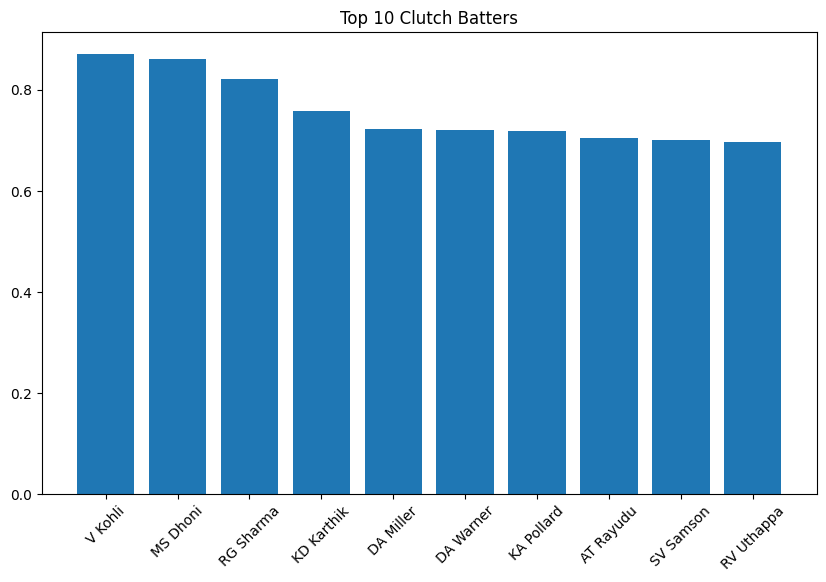

In [65]:
top10 = batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['batter'], top10['clutch_index'])
plt.xticks(rotation=45)
plt.title("Top 10 Clutch Batters")
plt.show()

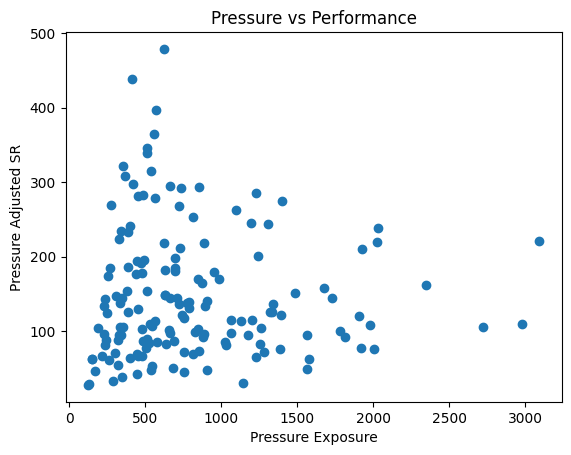

In [66]:
plt.scatter(batter_stats['pressure_exposure'], batter_stats['pressure_adjusted_sr'])
plt.xlabel("Pressure Exposure")
plt.ylabel("Pressure Adjusted SR")
plt.title("Pressure vs Performance")
plt.show()

In [67]:
chase_df['bowler_high_stakes'] = 0

In [68]:
chase_df['bowler_high_stakes'] = 0

In [69]:
chase_df['low_required_run_rate'] = np.where(chase_df['required_run_rate'] <= 6, 1, 0)

In [70]:
over_runs = chase_df.groupby(['match_id','over'])['total_runs'].sum().reset_index()

In [71]:
over_runs['prev_over_runs'] = over_runs.groupby('match_id')['total_runs'].shift(1)

In [72]:
chase_df = chase_df.merge(over_runs[['match_id','over','prev_over_runs']], 
                          on=['match_id','over'], how='left')

In [73]:
chase_df['prev_over_expensive'] = np.where(chase_df['prev_over_runs'] >= 15, 1, 0)

In [74]:
chase_df['set_batter'] = np.where(chase_df['batter_ball_number'] >= 20, 1, 0)

In [75]:
chase_df['small_total_defend'] = np.where(chase_df['target_runs'] <= 140, 1, 0)

In [76]:
chase_df['batting_momentum'] = np.where(chase_df['required_run_rate'] <= 7, 1, 0)

In [77]:
chase_df['bowler_pressure_score'] = (
    1.5 * chase_df['bowler_high_stakes'] +
    1.3 * chase_df['bowler_death_overs'] +
    1.1 * chase_df['low_required_run_rate'] +
    1.0 * chase_df['prev_over_expensive'] +
    0.8 * chase_df['set_batter'] +
    0.5 * chase_df['small_total_defend'] +
    0.5 * chase_df['batting_momentum']
)

KeyError: 'bowler_death_overs'

In [78]:
chase_df['bowler_death_overs'] = np.where(chase_df['over'] >= 15, 1, 0)

In [79]:
chase_df['bowler_pressure_score'] = (
    1.5 * chase_df['bowler_high_stakes'] +
    1.3 * chase_df['bowler_death_overs'] +
    1.1 * chase_df['low_required_run_rate'] +
    1.0 * chase_df['prev_over_expensive'] +
    0.8 * chase_df['set_batter'] +
    0.5 * chase_df['small_total_defend'] +
    0.5 * chase_df['batting_momentum']
)

In [80]:
chase_df[['over','ball','bowler','bowler_pressure_score']].head(20)

,over,ball,bowler,bowler_pressure_score
0,0,1,AB Dinda,0.0
1,0,2,AB Dinda,0.0
2,0,3,AB Dinda,0.0
3,0,4,AB Dinda,0.0
4,0,5,AB Dinda,0.0
5,0,6,AB Dinda,0.0
6,0,7,AB Dinda,0.0
7,1,1,I Sharma,0.0
8,1,2,I Sharma,0.0
9,1,3,I Sharma,0.0


In [81]:
chase_df['weighted_runs_conceded'] = chase_df['total_runs'] * chase_df['bowler_pressure_score']

In [82]:
chase_df['weighted_wickets'] = chase_df['is_wicket'] * chase_df['bowler_pressure_score']

In [83]:
chase_df['bowler_exposure'] = chase_df['bowler_pressure_score']

In [84]:
bowler_stats = chase_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('bowler', 'count'),
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    pressure_exposure=('bowler_exposure', 'sum')
).reset_index()

In [85]:
bowler_stats['economy'] = bowler_stats['runs_conceded'] / (bowler_stats['balls_bowled']/6)

In [86]:
bowler_stats['pressure_economy'] = bowler_stats['weighted_runs_conceded'] / (bowler_stats['balls_bowled']/6)

In [87]:
bowler_stats['eco_norm'] = 1 - (bowler_stats['pressure_economy'] / bowler_stats['pressure_economy'].max())

In [88]:
bowler_stats['wickets_norm'] = bowler_stats['weighted_wickets'] / bowler_stats['weighted_wickets'].max()
bowler_stats['exposure_norm'] = bowler_stats['pressure_exposure'] / bowler_stats['pressure_exposure'].max()
bowler_stats['balls_norm'] = bowler_stats['balls_bowled'] / bowler_stats['balls_bowled'].max()

In [89]:
bowler_stats['clutch_index'] = (
    0.4 * bowler_stats['eco_norm'] +
    0.3 * bowler_stats['wickets_norm'] +
    0.2 * bowler_stats['exposure_norm'] +
    0.1 * bowler_stats['balls_norm']
)

In [90]:
bowler_stats.sort_values(by='clutch_index', ascending=False).head(10)

,bowler,runs_conceded,balls_bowled,weighted_runs_conceded,weighted_wickets,pressure_exposure,economy,pressure_economy,eco_norm,wickets_norm,exposure_norm,balls_norm,clutch_index
109,DJ Bravo,2059,1581,3000.7,164.4,2097.4,7.814042,11.387856,0.890921,1.000000,1.000000,0.611842,0.917553
324,R Ashwin,2889,2584,2202.4,107.8,1844.8,6.708204,5.113932,0.951016,0.655718,0.879565,1.000000,0.853035
477,YS Chahal,2349,1924,2166.5,122.6,1666.8,7.325364,6.756237,0.935285,0.745742,0.794698,0.744582,0.831235
64,B Kumar,2490,2003,2889.1,107.2,1984.9,7.458812,8.654319,0.917104,0.652068,0.946362,0.775155,0.829250
399,SL Malinga,1757,1546,2142.9,128.6,1694.3,6.818887,8.316559,0.920339,0.782238,0.807810,0.598297,0.824199
7,A Mishra,2224,1833,2260.7,111.2,1734.1,7.279869,7.400000,0.929119,0.676399,0.826786,0.709365,0.810861
178,JJ Bumrah,1851,1540,2411.1,111.5,1782.4,7.211688,9.393896,0.910020,0.678224,0.849814,0.595975,0.797036
407,SP Narine,1937,1749,1991.9,98.3,1732.4,6.644940,6.833276,0.934547,0.597932,0.825975,0.676858,0.786079
317,PP Chawla,2175,1670,2494.8,89.6,1814.6,7.814371,8.963353,0.914144,0.545012,0.865166,0.646285,0.766823
149,HV Patel,1605,1174,1776.8,101.3,1250.8,8.202726,9.080750,0.913020,0.616180,0.596357,0.454334,0.714767


In [91]:
chase_df['is_dot']

0         0
1         0
2         1
3         0
4         0
         ..
125736    0
125737    0
125738    0
125739    0
125740    0
Name: is_dot, Length: 125741, dtype: int64

In [92]:
chase_df['weighted_dot_balls'] = chase_df['is_dot'] * chase_df['bowler_pressure_score']

In [93]:
bowler_stats = chase_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('bowler', 'count'),
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum'),
    pressure_exposure=('bowler_exposure', 'sum')
).reset_index()

In [94]:
bowler_stats['dot_norm'] = bowler_stats['weighted_dot_balls'] / bowler_stats['weighted_dot_balls'].max()

In [95]:
bowler_stats['clutch_index'] = (
    0.3 * bowler_stats['eco_norm'] +
    0.25 * bowler_stats['wickets_norm'] +
    0.2 * bowler_stats['dot_norm'] +   # 🔥 NEW
    0.15 * bowler_stats['exposure_norm'] +
    0.1 * bowler_stats['balls_norm']
)

KeyError: 'eco_norm'

In [96]:
bowler_stats['economy'] = bowler_stats['runs_conceded'] / (bowler_stats['balls_bowled'] / 6)
bowler_stats['pressure_economy'] = bowler_stats['weighted_runs_conceded'] / (bowler_stats['balls_bowled'] / 6)

In [97]:
bowler_stats['eco_norm'] = 1 - (bowler_stats['pressure_economy'] / bowler_stats['pressure_economy'].max())
bowler_stats['wickets_norm'] = bowler_stats['weighted_wickets'] / bowler_stats['weighted_wickets'].max()
bowler_stats['dot_norm'] = bowler_stats['weighted_dot_balls'] / bowler_stats['weighted_dot_balls'].max()
bowler_stats['exposure_norm'] = bowler_stats['pressure_exposure'] / bowler_stats['pressure_exposure'].max()
bowler_stats['balls_norm'] = bowler_stats['balls_bowled'] / bowler_stats['balls_bowled'].max()

In [98]:
bowler_stats['clutch_index'] = (
    0.3 * bowler_stats['eco_norm'] +
    0.25 * bowler_stats['wickets_norm'] +
    0.2 * bowler_stats['dot_norm'] +
    0.15 * bowler_stats['exposure_norm'] +
    0.1 * bowler_stats['balls_norm']
)

In [99]:
bowler_stats.sort_values(by='clutch_index', ascending=False).head(10)

,bowler,runs_conceded,balls_bowled,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,pressure_exposure,dot_norm,economy,pressure_economy,eco_norm,wickets_norm,exposure_norm,balls_norm,clutch_index
109,DJ Bravo,2059,1581,3000.7,164.4,614.6,2097.4,0.940187,7.814042,11.387856,0.890921,1.000000,1.000000,0.611842,0.916498
324,R Ashwin,2889,2584,2202.4,107.8,596.2,1844.8,0.912039,6.708204,5.113932,0.951016,0.655718,0.879565,1.000000,0.863577
64,B Kumar,2490,2003,2889.1,107.2,611.8,1984.9,0.935903,7.458812,8.654319,0.917104,0.652068,0.946362,0.775155,0.844799
477,YS Chahal,2349,1924,2166.5,122.6,554.9,1666.8,0.848860,7.325364,6.756237,0.935285,0.745742,0.794698,0.744582,0.830456
399,SL Malinga,1757,1546,2142.9,128.6,563.3,1694.3,0.861710,6.818887,8.316559,0.920339,0.782238,0.807810,0.598297,0.825005
7,A Mishra,2224,1833,2260.7,111.2,593.1,1734.1,0.907297,7.279869,7.400000,0.929119,0.676399,0.826786,0.709365,0.824249
407,SP Narine,1937,1749,1991.9,98.3,653.7,1732.4,1.000000,6.644940,6.833276,0.934547,0.597932,0.825975,0.676858,0.821429
178,JJ Bumrah,1851,1540,2411.1,111.5,581.5,1782.4,0.889552,7.211688,9.393896,0.910020,0.678224,0.849814,0.595975,0.807542
317,PP Chawla,2175,1670,2494.8,89.6,607.4,1814.6,0.929172,7.814371,8.963353,0.914144,0.545012,0.865166,0.646285,0.790734
127,DW Steyn,1444,1284,1739.3,76.7,596.0,1433.3,0.911733,6.747664,8.127570,0.922150,0.466545,0.683370,0.496904,0.727824


In [100]:
bowler_stats['clutch_index'] = (
    0.28 * bowler_stats['eco_norm'] +
    0.22 * bowler_stats['wickets_norm'] +
    0.25 * bowler_stats['dot_norm'] +   # 🔥 increased
    0.15 * bowler_stats['exposure_norm'] +
    0.1 * bowler_stats['balls_norm']
)

In [101]:
bowler_stats.sort_values(by='clutch_index', ascending=False).head(10)

,bowler,runs_conceded,balls_bowled,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,pressure_exposure,dot_norm,economy,pressure_economy,eco_norm,wickets_norm,exposure_norm,balls_norm,clutch_index
109,DJ Bravo,2059,1581,3000.7,164.4,614.6,2097.4,0.940187,7.814042,11.387856,0.890921,1.000000,1.000000,0.611842,0.915689
324,R Ashwin,2889,2584,2202.4,107.8,596.2,1844.8,0.912039,6.708204,5.113932,0.951016,0.655718,0.879565,1.000000,0.870487
64,B Kumar,2490,2003,2889.1,107.2,611.8,1984.9,0.935903,7.458812,8.654319,0.917104,0.652068,0.946362,0.775155,0.853690
407,SP Narine,1937,1749,1991.9,98.3,653.7,1732.4,1.000000,6.644940,6.833276,0.934547,0.597932,0.825975,0.676858,0.834800
477,YS Chahal,2349,1924,2166.5,122.6,554.9,1666.8,0.848860,7.325364,6.756237,0.935285,0.745742,0.794698,0.744582,0.831821
7,A Mishra,2224,1833,2260.7,111.2,593.1,1734.1,0.907297,7.279869,7.400000,0.929119,0.676399,0.826786,0.709365,0.830740
399,SL Malinga,1757,1546,2142.9,128.6,563.3,1694.3,0.861710,6.818887,8.316559,0.920339,0.782238,0.807810,0.598297,0.826216
178,JJ Bumrah,1851,1540,2411.1,111.5,581.5,1782.4,0.889552,7.211688,9.393896,0.910020,0.678224,0.849814,0.595975,0.813472
317,PP Chawla,2175,1670,2494.8,89.6,607.4,1814.6,0.929172,7.814371,8.963353,0.914144,0.545012,0.865166,0.646285,0.802560
127,DW Steyn,1444,1284,1739.3,76.7,596.0,1433.3,0.911733,6.747664,8.127570,0.922150,0.466545,0.683370,0.496904,0.740971


In [102]:
death_batters = chase_df[chase_df['death_overs'] == 1].groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

death_batters['strike_rate'] = (death_batters['runs'] / death_batters['balls']) * 100
death_batters['pressure_adjusted_sr'] = (death_batters['weighted_runs'] / death_batters['balls']) * 100

death_batters = death_batters[death_batters['balls'] >= 30]

death_batters.sort_values(by='pressure_adjusted_sr', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr
475,T Stubbs,95,38,253.5,250.000000,667.105263
221,KK Cooper,57,30,185.1,190.000000,617.000000
338,PJ Cummins,159,82,488.9,193.902439,596.219512
357,R Dravid,72,41,234.3,175.609756,571.463415
250,LS Livingstone,148,68,362.4,217.647059,532.941176
381,RK Singh,274,139,739.0,197.122302,531.654676
84,BCJ Cutting,78,44,227.8,177.272727,517.727273
389,RS Bopara,72,34,172.1,211.764706,506.176471
258,M Morkel,106,63,314.9,168.253968,499.841270
394,Rashid Khan,310,178,886.5,174.157303,498.033708


In [103]:
high_rrr_batters = chase_df[chase_df['high_required_run_rate'] == 1].groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

high_rrr_batters['strike_rate'] = (high_rrr_batters['runs'] / high_rrr_batters['balls']) * 100
high_rrr_batters['pressure_adjusted_sr'] = (high_rrr_batters['weighted_runs'] / high_rrr_batters['balls']) * 100

high_rrr_batters = high_rrr_batters[high_rrr_batters['balls'] >= 20]

high_rrr_batters.sort_values(by='pressure_adjusted_sr', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr
385,R Rampaul,32,21,122.7,152.380952,584.285714
236,KK Cooper,53,31,169.8,170.967742,547.741935
427,S Aravind,34,25,136.6,136.000000,546.400000
120,D Pretorius,38,23,120.7,165.217391,524.782609
70,Arshad Khan,55,31,162.1,177.419355,522.903226
423,Rashid Khan,257,151,777.2,170.198675,514.701987
362,PJ Cummins,194,116,561.0,167.241379,483.620690
342,Naman Dhir,77,39,182.8,197.435897,468.717949
122,D Wiese,71,47,217.5,151.063830,462.765957
195,JC Archer,102,68,304.9,150.000000,448.382353


In [104]:
death_df = chase_df[chase_df['death_overs'] == 1]

In [105]:
death_batters = death_df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [106]:
death_batters['strike_rate'] = (death_batters['runs'] / death_batters['balls']) * 100
death_batters['pressure_adjusted_sr'] = (death_batters['weighted_runs'] / death_batters['balls']) * 100

In [107]:
death_batters = death_batters[death_batters['balls'] >= 50]

In [108]:
death_batters.sort_values(by='pressure_adjusted_sr', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr
338,PJ Cummins,159,82,488.9,193.902439,596.219512
250,LS Livingstone,148,68,362.4,217.647059,532.941176
381,RK Singh,274,139,739.0,197.122302,531.654676
258,M Morkel,106,63,314.9,168.253968,499.841270
394,Rashid Khan,310,178,886.5,174.157303,498.033708
197,JM Sharma,90,56,272.2,160.714286,486.071429
79,BA Stokes,121,57,276.2,212.280702,484.561404
97,CH Morris,236,135,653.7,174.814815,484.222222
479,TH David,336,178,848.8,188.764045,476.853933
114,D Wiese,77,50,238.4,154.000000,476.800000


In [109]:
death_batters = death_batters[death_batters['balls'] >= 80]

In [110]:
death_batters['exposure'] = death_df.groupby('batter')['batter_pressure_score'].sum().values

ValueError: Length of values (522) does not match length of index (102)

In [111]:
death_exposure = death_df.groupby('batter').agg(
    exposure=('batter_pressure_score', 'sum')
).reset_index()

In [112]:
death_batters = death_batters.merge(death_exposure, on='batter', how='left')

In [113]:
death_batters['exposure_norm'] = death_batters['exposure'] / death_batters['exposure'].max()

In [114]:
death_batters['sr_norm'] = death_batters['pressure_adjusted_sr'] / death_batters['pressure_adjusted_sr'].max()

death_batters['death_score'] = (
    0.7 * death_batters['sr_norm'] +
    0.3 * death_batters['exposure_norm']
)

In [115]:
death_batters.sort_values(by='death_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,death_score
60,PJ Cummins,159,82,488.9,193.902439,596.219512,289.6,0.145097,1.000000,0.743529
52,MS Dhoni,1281,796,2898.0,160.929648,364.070352,1995.9,1.000000,0.610631,0.727442
71,RK Singh,274,139,739.0,197.122302,531.654676,392.1,0.196453,0.891710,0.683133
74,Rashid Khan,310,178,886.5,174.157303,498.033708,566.0,0.283581,0.835319,0.669798
15,DA Miller,735,413,1719.3,177.966102,416.295400,1012.0,0.507039,0.698225,0.640869
91,TH David,336,178,848.8,188.764045,476.853933,487.5,0.244251,0.799796,0.633132
3,AD Russell,452,275,1185.5,164.363636,431.090909,825.6,0.413648,0.723041,0.630223
14,CH Morris,236,135,653.7,174.814815,484.222222,400.5,0.200661,0.812154,0.628706
66,R Tewatia,421,262,1110.2,160.687023,423.740458,778.6,0.390100,0.710712,0.614528
38,KA Pollard,787,469,1723.3,167.803838,367.441365,1183.6,0.593016,0.616285,0.609304


In [116]:
death_batters['sr_norm'] = np.log1p(death_batters['pressure_adjusted_sr']) / np.log1p(death_batters['pressure_adjusted_sr'].max())

death_batters['death_score'] = (
    0.6 * death_batters['sr_norm'] +
    0.4 * death_batters['exposure_norm']
)

In [117]:
death_batters.sort_values(by='death_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,death_score
52,MS Dhoni,1281,796,2898.0,160.929648,364.070352,1995.9,1.000000,0.923002,0.953801
68,RA Jadeja,708,490,1660.8,144.489796,338.938776,1267.7,0.635152,0.911844,0.801167
38,KA Pollard,787,469,1723.3,167.803838,367.441365,1183.6,0.593016,0.924440,0.791870
15,DA Miller,735,413,1719.3,177.966102,416.295400,1012.0,0.507039,0.943918,0.769167
39,KD Karthik,702,434,1540.2,161.751152,354.884793,1047.4,0.524776,0.919015,0.761319
3,AD Russell,452,275,1185.5,164.363636,431.090909,825.6,0.413648,0.949369,0.735081
66,R Tewatia,421,262,1110.2,160.687023,423.740458,778.6,0.390100,0.946685,0.724051
8,AR Patel,378,265,1031.1,142.641509,389.094340,785.8,0.393707,0.933373,0.717507
94,V Kohli,551,320,1207.4,172.187500,377.312500,762.8,0.382183,0.928576,0.710019
100,YK Pathan,577,350,1200.2,164.857143,342.914286,790.2,0.395912,0.913663,0.706562


In [118]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

,batter,total_runs,total_balls,weighted_runs,pressure_exposure,dismissals,strike_rate,pressure_adjusted_sr,clutch_index,sr_norm,exposure_norm,balls_norm
581,V Kohli,3604,2759,3045.4,2974.9,100,130.627039,110.380573,0.870507,0.763457,0.962595,1.000000
341,MS Dhoni,2178,1693,3753.2,3090.5,61,128.647372,221.689309,0.860570,0.875688,1.000000,0.613628
435,RG Sharma,3028,2468,2599.2,2720.8,107,122.690438,105.316045,0.820977,0.755918,0.880375,0.894527
254,KD Karthik,2099,1629,2637.3,2345.6,84,128.852056,161.896869,0.758298,0.825040,0.758971,0.590431
133,DA Miller,1699,1233,2715.1,2022.8,38,137.793998,220.202758,0.723039,0.874603,0.654522,0.446901
134,DA Warner,3285,2395,1825.5,2004.6,82,137.160752,76.221294,0.720265,0.704123,0.648633,0.868068
249,KA Pollard,1550,1081,2585.3,2028.8,55,143.385754,239.158187,0.719262,0.887922,0.656463,0.391809
60,AT Rayudu,2201,1831,1988.6,1977.6,77,120.207537,108.607318,0.705127,0.760857,0.639896,0.663646
527,SV Samson,2302,1754,2116.9,1906.6,79,131.242873,120.689852,0.701123,0.777797,0.616923,0.635738
457,RV Uthappa,2832,2173,1697.0,1917.5,107,130.326737,78.094800,0.697659,0.708006,0.620450,0.787604


In [119]:
bowler_stats.sort_values(by='clutch_index', ascending=False).head(10)

,bowler,runs_conceded,balls_bowled,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,pressure_exposure,dot_norm,economy,pressure_economy,eco_norm,wickets_norm,exposure_norm,balls_norm,clutch_index
109,DJ Bravo,2059,1581,3000.7,164.4,614.6,2097.4,0.940187,7.814042,11.387856,0.890921,1.000000,1.000000,0.611842,0.915689
324,R Ashwin,2889,2584,2202.4,107.8,596.2,1844.8,0.912039,6.708204,5.113932,0.951016,0.655718,0.879565,1.000000,0.870487
64,B Kumar,2490,2003,2889.1,107.2,611.8,1984.9,0.935903,7.458812,8.654319,0.917104,0.652068,0.946362,0.775155,0.853690
407,SP Narine,1937,1749,1991.9,98.3,653.7,1732.4,1.000000,6.644940,6.833276,0.934547,0.597932,0.825975,0.676858,0.834800
477,YS Chahal,2349,1924,2166.5,122.6,554.9,1666.8,0.848860,7.325364,6.756237,0.935285,0.745742,0.794698,0.744582,0.831821
7,A Mishra,2224,1833,2260.7,111.2,593.1,1734.1,0.907297,7.279869,7.400000,0.929119,0.676399,0.826786,0.709365,0.830740
399,SL Malinga,1757,1546,2142.9,128.6,563.3,1694.3,0.861710,6.818887,8.316559,0.920339,0.782238,0.807810,0.598297,0.826216
178,JJ Bumrah,1851,1540,2411.1,111.5,581.5,1782.4,0.889552,7.211688,9.393896,0.910020,0.678224,0.849814,0.595975,0.813472
317,PP Chawla,2175,1670,2494.8,89.6,607.4,1814.6,0.929172,7.814371,8.963353,0.914144,0.545012,0.865166,0.646285,0.802560
127,DW Steyn,1444,1284,1739.3,76.7,596.0,1433.3,0.911733,6.747664,8.127570,0.922150,0.466545,0.683370,0.496904,0.740971


In [120]:
high_rrr_df = chase_df[chase_df['high_required_run_rate'] == 1]

In [121]:
high_rrr_batters = high_rrr_df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [122]:
high_rrr_batters['strike_rate'] = (high_rrr_batters['runs'] / high_rrr_batters['balls']) * 100
high_rrr_batters['pressure_adjusted_sr'] = (high_rrr_batters['weighted_runs'] / high_rrr_batters['balls']) * 100

In [123]:
high_rrr_batters = high_rrr_batters[high_rrr_batters['balls'] >= 50]

In [124]:
high_rrr_exposure = high_rrr_df.groupby('batter').agg(
    exposure=('batter_pressure_score', 'sum')
).reset_index()

high_rrr_batters = high_rrr_batters.merge(high_rrr_exposure, on='batter', how='left')

In [125]:
high_rrr_batters['exposure_norm'] = high_rrr_batters['exposure'] / high_rrr_batters['exposure'].max()

In [126]:
high_rrr_batters['sr_norm'] = np.log1p(high_rrr_batters['pressure_adjusted_sr']) / np.log1p(high_rrr_batters['pressure_adjusted_sr'].max())

In [127]:
high_rrr_batters['rrr_score'] = (
    0.6 * high_rrr_batters['sr_norm'] +
    0.4 * high_rrr_batters['exposure_norm']
)

In [128]:
high_rrr_batters.sort_values(by='rrr_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,rrr_score
120,MS Dhoni,1309,1027,2859.0,127.458617,278.383642,2354.7,1.000000,0.901859,0.941115
202,V Kohli,1216,954,2283.9,127.463312,239.402516,1965.5,0.834714,0.877798,0.860564
156,RG Sharma,1182,915,2132.9,129.180328,233.103825,1846.5,0.784176,0.873547,0.837799
87,KD Karthik,987,771,2030.5,128.015564,263.359274,1707.6,0.725188,0.893008,0.825880
85,KA Pollard,1042,748,2105.3,139.304813,281.457219,1662.5,0.706035,0.903611,0.824580
41,DA Miller,1061,732,2184.5,144.945355,298.428962,1589.0,0.674821,0.912953,0.817700
153,RA Jadeja,833,659,1836.0,126.403642,278.603945,1553.4,0.659702,0.901985,0.805072
8,AD Russell,740,485,1631.7,152.577320,336.432990,1234.5,0.524271,0.932085,0.768960
5,AB de Villiers,805,541,1614.1,148.798521,298.354898,1151.6,0.489064,0.912914,0.743374
212,YK Pathan,815,546,1595.3,149.267399,292.179487,1156.7,0.491230,0.909576,0.742238


In [129]:
high_rrr_batters.sort_values(by='rrr_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,rrr_score
120,MS Dhoni,1309,1027,2859.0,127.458617,278.383642,2354.7,1.000000,0.901859,0.941115
202,V Kohli,1216,954,2283.9,127.463312,239.402516,1965.5,0.834714,0.877798,0.860564
156,RG Sharma,1182,915,2132.9,129.180328,233.103825,1846.5,0.784176,0.873547,0.837799
87,KD Karthik,987,771,2030.5,128.015564,263.359274,1707.6,0.725188,0.893008,0.825880
85,KA Pollard,1042,748,2105.3,139.304813,281.457219,1662.5,0.706035,0.903611,0.824580
41,DA Miller,1061,732,2184.5,144.945355,298.428962,1589.0,0.674821,0.912953,0.817700
153,RA Jadeja,833,659,1836.0,126.403642,278.603945,1553.4,0.659702,0.901985,0.805072
8,AD Russell,740,485,1631.7,152.577320,336.432990,1234.5,0.524271,0.932085,0.768960
5,AB de Villiers,805,541,1614.1,148.798521,298.354898,1151.6,0.489064,0.912914,0.743374
212,YK Pathan,815,546,1595.3,149.267399,292.179487,1156.7,0.491230,0.909576,0.742238


In [130]:
collapse_df = chase_df[chase_df['collapse_few_wickets'] == 1]

In [131]:
collapse_batters = collapse_df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [132]:
collapse_batters['strike_rate'] = (collapse_batters['runs'] / collapse_batters['balls']) * 100
collapse_batters['pressure_adjusted_sr'] = (collapse_batters['weighted_runs'] / collapse_batters['balls']) * 100

In [133]:
collapse_batters = collapse_batters[collapse_batters['balls'] >= 40]

In [134]:
collapse_exposure = collapse_df.groupby('batter').agg(
    exposure=('batter_pressure_score', 'sum')
).reset_index()

collapse_batters = collapse_batters.merge(collapse_exposure, on='batter', how='left')

In [135]:
collapse_batters['exposure_norm'] = collapse_batters['exposure'] / collapse_batters['exposure'].max()

In [136]:
collapse_batters['sr_norm'] = np.log1p(collapse_batters['pressure_adjusted_sr']) / np.log1p(collapse_batters['pressure_adjusted_sr'].max())

In [137]:
collapse_batters['collapse_score'] = (
    0.6 * collapse_batters['sr_norm'] +
    0.4 * collapse_batters['exposure_norm']
)

In [138]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score
4,B Kumar,185,206,632.0,89.805825,306.796117,772.0,1.000000,0.877018,0.926211
43,UT Yadav,153,139,535.0,110.071942,384.892086,534.8,0.692746,0.911631,0.824077
0,A Mishra,145,165,445.4,87.878788,269.939394,559.6,0.724870,0.857495,0.804445
18,Kuldeep Yadav,96,139,333.4,69.064748,239.856115,532.2,0.689378,0.839479,0.779439
25,P Kumar,137,123,442.2,111.382114,359.512195,440.0,0.569948,0.901217,0.768709
22,MS Dhoni,184,105,543.2,175.238095,517.333333,349.7,0.452979,0.956796,0.755269
31,R Vinay Kumar,115,115,370.9,100.000000,322.521739,409.3,0.530181,0.884645,0.742860
30,R Tewatia,132,103,407.7,128.155340,395.825243,355.2,0.460104,0.915907,0.733586
27,PP Chawla,105,101,351.4,103.960396,347.920792,375.3,0.486140,0.896214,0.732184
36,Rashid Khan,119,82,397.3,145.121951,484.512195,307.0,0.397668,0.946783,0.727137


In [139]:
collapse_batters = collapse_batters[collapse_batters['runs'] >= 200]

In [140]:
valid_batters = batter_stats[batter_stats['total_balls'] >= 300]['batter']
collapse_batters = collapse_batters[collapse_batters['batter'].isin(valid_batters)]

In [141]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score


In [142]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score


In [143]:
valid_batters = batter_stats[batter_stats['total_balls'] >= 200]['batter']
collapse_batters = collapse_batters[collapse_batters['batter'].isin(valid_batters)]

In [144]:
collapse_batters = collapse_batters[collapse_batters['balls'] >= 30]

In [145]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score


In [146]:
death_batters.sort_values(by='death_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,death_score
52,MS Dhoni,1281,796,2898.0,160.929648,364.070352,1995.9,1.000000,0.923002,0.953801
68,RA Jadeja,708,490,1660.8,144.489796,338.938776,1267.7,0.635152,0.911844,0.801167
38,KA Pollard,787,469,1723.3,167.803838,367.441365,1183.6,0.593016,0.924440,0.791870
15,DA Miller,735,413,1719.3,177.966102,416.295400,1012.0,0.507039,0.943918,0.769167
39,KD Karthik,702,434,1540.2,161.751152,354.884793,1047.4,0.524776,0.919015,0.761319
3,AD Russell,452,275,1185.5,164.363636,431.090909,825.6,0.413648,0.949369,0.735081
66,R Tewatia,421,262,1110.2,160.687023,423.740458,778.6,0.390100,0.946685,0.724051
8,AR Patel,378,265,1031.1,142.641509,389.094340,785.8,0.393707,0.933373,0.717507
94,V Kohli,551,320,1207.4,172.187500,377.312500,762.8,0.382183,0.928576,0.710019
100,YK Pathan,577,350,1200.2,164.857143,342.914286,790.2,0.395912,0.913663,0.706562


In [147]:
chase_df['collapse_situation'] = np.where(chase_df['wickets_fallen'] >= 5, 1, 0)

In [148]:
collapse_df = chase_df[chase_df['collapse_situation'] == 1]

In [149]:
collapse_batters = collapse_df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [150]:
collapse_batters['strike_rate'] = (collapse_batters['runs'] / collapse_batters['balls']) * 100
collapse_batters['pressure_adjusted_sr'] = (collapse_batters['weighted_runs'] / collapse_batters['balls']) * 100

In [151]:
collapse_batters = collapse_batters[collapse_batters['balls'] >= 40]

In [152]:
collapse_exposure = collapse_df.groupby('batter').agg(
    exposure=('batter_pressure_score', 'sum')
).reset_index()

collapse_batters = collapse_batters.merge(collapse_exposure, on='batter', how='left')

In [153]:
collapse_batters['exposure_norm'] = collapse_batters['exposure'] / collapse_batters['exposure'].max()
collapse_batters['sr_norm'] = np.log1p(collapse_batters['pressure_adjusted_sr']) / np.log1p(collapse_batters['pressure_adjusted_sr'].max())

In [154]:
collapse_batters['collapse_score'] = (
    0.6 * collapse_batters['sr_norm'] +
    0.4 * collapse_batters['exposure_norm']
)

In [155]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score
89,MS Dhoni,770,480,1718.9,160.416667,358.104167,1183.0,1.000000,0.931532,0.958919
11,AR Patel,614,442,1355.2,138.914027,306.606335,1078.1,0.911327,0.907024,0.908745
115,RA Jadeja,633,473,1263.9,133.826638,267.209302,1026.5,0.867709,0.885325,0.878279
113,R Tewatia,453,373,1036.3,121.447721,277.828418,935.4,0.790702,0.891473,0.851164
17,B Kumar,207,233,684.0,88.841202,293.562232,853.0,0.721048,0.900164,0.828518
45,Harbhajan Singh,318,256,801.8,124.218750,313.203125,769.4,0.650380,0.910384,0.806382
66,KD Karthik,502,337,1016.5,148.961424,301.632047,774.3,0.654522,0.904443,0.804475
65,KA Pollard,458,324,944.8,141.358025,291.604938,773.8,0.654100,0.899108,0.801105
125,Rashid Khan,342,201,962.2,170.149254,478.706468,623.8,0.527303,0.977377,0.797348
8,AD Russell,493,309,939.2,159.546926,303.948220,725.3,0.613102,0.905650,0.788631


In [156]:
collapse_batters.sort_values(by='collapse_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,collapse_score
89,MS Dhoni,770,480,1718.9,160.416667,358.104167,1183.0,1.000000,0.931532,0.958919
11,AR Patel,614,442,1355.2,138.914027,306.606335,1078.1,0.911327,0.907024,0.908745
115,RA Jadeja,633,473,1263.9,133.826638,267.209302,1026.5,0.867709,0.885325,0.878279
113,R Tewatia,453,373,1036.3,121.447721,277.828418,935.4,0.790702,0.891473,0.851164
17,B Kumar,207,233,684.0,88.841202,293.562232,853.0,0.721048,0.900164,0.828518
45,Harbhajan Singh,318,256,801.8,124.218750,313.203125,769.4,0.650380,0.910384,0.806382
66,KD Karthik,502,337,1016.5,148.961424,301.632047,774.3,0.654522,0.904443,0.804475
65,KA Pollard,458,324,944.8,141.358025,291.604938,773.8,0.654100,0.899108,0.801105
125,Rashid Khan,342,201,962.2,170.149254,478.706468,623.8,0.527303,0.977377,0.797348
8,AD Russell,493,309,939.2,159.546926,303.948220,725.3,0.613102,0.905650,0.788631


In [157]:
big_target_df = chase_df[chase_df['big_target_chase'] == 1]

In [158]:
big_target_batters = big_target_df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [159]:
big_target_batters['strike_rate'] = (big_target_batters['runs'] / big_target_batters['balls']) * 100
big_target_batters['pressure_adjusted_sr'] = (big_target_batters['weighted_runs'] / big_target_batters['balls']) * 100

In [160]:
big_target_batters = big_target_batters[big_target_batters['balls'] >= 80]

In [161]:
big_target_exposure = big_target_df.groupby('batter').agg(
    exposure=('batter_pressure_score', 'sum')
).reset_index()

big_target_batters = big_target_batters.merge(big_target_exposure, on='batter', how='left')

In [162]:
big_target_batters['exposure_norm'] = big_target_batters['exposure'] / big_target_batters['exposure'].max()

In [163]:
big_target_batters['sr_norm'] = np.log1p(big_target_batters['pressure_adjusted_sr']) / np.log1p(big_target_batters['pressure_adjusted_sr'].max())

In [164]:
big_target_batters['big_target_score'] = (
    0.6 * big_target_batters['sr_norm'] +
    0.4 * big_target_batters['exposure_norm']
)

In [165]:
big_target_batters.sort_values(by='big_target_score', ascending=False).head(10)

,batter,runs,balls,weighted_runs,strike_rate,pressure_adjusted_sr,exposure,exposure_norm,sr_norm,big_target_score
130,V Kohli,1494,1111,2351.5,134.473447,211.656166,1998.8,1.000000,0.844052,0.906431
52,KD Karthik,836,657,1671.1,127.245053,254.353120,1418.7,0.709776,0.872867,0.807631
27,DA Miller,913,576,1938.9,158.506944,336.614583,1267.2,0.633980,0.916845,0.803699
77,MS Dhoni,724,536,1606.1,135.074627,299.645522,1259.8,0.630278,0.898581,0.791260
5,AD Russell,641,389,1416.3,164.781491,364.087404,987.7,0.494146,0.929165,0.755158
119,SV Samson,1164,793,1600.0,146.784363,201.765448,1229.7,0.615219,0.836552,0.748019
97,RG Sharma,846,643,1262.2,131.570762,196.298600,1168.7,0.584701,0.832248,0.733229
10,AR Patel,472,343,1092.9,137.609329,318.629738,886.3,0.443416,0.908224,0.722301
79,N Pooran,675,375,1333.5,180.000000,355.600000,831.9,0.416200,0.925461,0.721756
55,KL Rahul,782,603,1202.0,129.684909,199.336650,1067.4,0.534020,0.834654,0.714401


In [166]:
death_bowl_df = chase_df[chase_df['bowler_death_overs'] == 1]

In [167]:
death_bowlers = death_bowl_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls=('bowler', 'count'),
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum')
).reset_index()

In [168]:
death_bowlers['economy'] = death_bowlers['runs_conceded'] / (death_bowlers['balls'] / 6)
death_bowlers['pressure_economy'] = death_bowlers['weighted_runs_conceded'] / (death_bowlers['balls'] / 6)

In [169]:
death_bowlers = death_bowlers[death_bowlers['balls'] >= 60]

In [170]:
death_bowlers['eco_norm'] = 1 - (death_bowlers['pressure_economy'] / death_bowlers['pressure_economy'].max())
death_bowlers['wickets_norm'] = death_bowlers['weighted_wickets'] / death_bowlers['weighted_wickets'].max()
death_bowlers['dot_norm'] = death_bowlers['weighted_dot_balls'] / death_bowlers['weighted_dot_balls'].max()

In [171]:
death_bowlers['death_bowling_score'] = (
    0.4 * death_bowlers['eco_norm'] +
    0.3 * death_bowlers['wickets_norm'] +
    0.3 * death_bowlers['dot_norm']
)

In [172]:
death_bowlers.sort_values(by='death_bowling_score', ascending=False).head(10)

,bowler,runs_conceded,balls,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,economy,pressure_economy,eco_norm,wickets_norm,dot_norm,death_bowling_score
86,DJ Bravo,914,637,2036.6,140.7,395.2,8.609105,19.183046,0.373668,1.000000,1.000000,0.749467
316,SL Malinga,730,580,1594.0,110.2,359.5,7.551724,16.489655,0.461608,0.783227,0.909666,0.692511
140,JJ Bumrah,766,580,1708.9,89.1,382.1,7.924138,17.678276,0.422799,0.633262,0.966852,0.649154
53,B Kumar,883,601,1892.1,85.4,319.4,8.815308,18.889517,0.383252,0.606965,0.808198,0.577850
114,HV Patel,569,403,1225.5,84.6,264.3,8.471464,18.245658,0.404274,0.601279,0.668775,0.542726
324,SP Narine,397,342,780.1,51.7,250.9,6.964912,13.685965,0.553149,0.367448,0.634868,0.521955
100,DW Steyn,429,341,923.2,55.3,276.7,7.548387,16.243988,0.469629,0.393035,0.700152,0.515808
385,YS Chahal,474,332,964.9,64.8,177.1,8.566265,17.437952,0.430646,0.460554,0.448128,0.444863
258,R Ashwin,369,300,730.5,46.4,165.5,7.380000,14.610000,0.522979,0.329780,0.418775,0.433758
155,K Rabada,390,262,854.6,61.8,180.1,8.931298,19.570992,0.361001,0.439232,0.455719,0.412886


In [173]:
set_batter_df = chase_df[chase_df['set_batter'] == 1]

In [174]:
set_bowlers = set_batter_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls=('bowler', 'count'),
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum')
).reset_index()

In [175]:
set_bowlers['economy'] = set_bowlers['runs_conceded'] / (set_bowlers['balls'] / 6)
set_bowlers['pressure_economy'] = set_bowlers['weighted_runs_conceded'] / (set_bowlers['balls'] / 6)

In [176]:
set_bowlers = set_bowlers[set_bowlers['balls'] >= 80]

In [177]:
set_bowlers['eco_norm'] = 1 - (set_bowlers['pressure_economy'] / set_bowlers['pressure_economy'].max())
set_bowlers['wickets_norm'] = set_bowlers['weighted_wickets'] / set_bowlers['weighted_wickets'].max()
set_bowlers['dot_norm'] = set_bowlers['weighted_dot_balls'] / set_bowlers['weighted_dot_balls'].max()

In [178]:
set_bowlers['set_batter_score'] = (
    0.4 * set_bowlers['eco_norm'] +
    0.3 * set_bowlers['wickets_norm'] +
    0.3 * set_bowlers['dot_norm']
)

In [179]:
set_bowlers.sort_values(by='set_batter_score', ascending=False).head(10)

,bowler,runs_conceded,balls,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,economy,pressure_economy,eco_norm,wickets_norm,dot_norm,set_batter_score
452,YS Chahal,874,683,1339.5,84.8,296.6,7.677892,11.767204,0.553962,1.000000,0.859461,0.779423
6,A Mishra,994,708,1446.8,62.5,315.8,8.423729,12.261017,0.535244,0.737028,0.915097,0.709735
308,R Ashwin,904,726,1180.2,51.0,248.5,7.471074,9.753719,0.630284,0.601415,0.720081,0.648562
301,PP Chawla,895,645,1511.4,42.9,345.1,8.325581,14.059535,0.467071,0.505896,1.000000,0.638597
323,RA Jadeja,1045,722,1546.0,39.7,327.8,8.684211,12.847645,0.513008,0.468160,0.949870,0.630612
102,DJ Bravo,878,586,1772.5,71.9,270.9,8.989761,18.148464,0.312080,0.847877,0.784990,0.614692
142,Harbhajan Singh,631,532,849.7,46.1,222.6,7.116541,9.583083,0.636752,0.543632,0.645030,0.611299
386,SP Narine,632,529,1108.0,37.1,282.8,7.168242,12.567108,0.523642,0.437500,0.819473,0.586548
343,Rashid Khan,642,495,1051.5,42.7,220.1,7.781818,12.745455,0.516882,0.503538,0.637786,0.549150
379,SL Malinga,493,375,1131.5,57.5,212.6,7.888000,18.104000,0.313765,0.678066,0.616053,0.513742


In [180]:
small_total_df = chase_df[chase_df['small_total_defend'] == 1]

In [181]:
small_total_bowlers = small_total_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls=('bowler', 'count'),
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum')
).reset_index()

In [182]:
small_total_bowlers['economy'] = small_total_bowlers['runs_conceded'] / (small_total_bowlers['balls'] / 6)
small_total_bowlers['pressure_economy'] = small_total_bowlers['weighted_runs_conceded'] / (small_total_bowlers['balls'] / 6)

In [183]:
small_total_bowlers = small_total_bowlers[small_total_bowlers['balls'] >= 50]

In [184]:
small_total_bowlers['eco_norm'] = 1 - (small_total_bowlers['pressure_economy'] / small_total_bowlers['pressure_economy'].max())
small_total_bowlers['wickets_norm'] = small_total_bowlers['weighted_wickets'] / small_total_bowlers['weighted_wickets'].max()
small_total_bowlers['dot_norm'] = small_total_bowlers['weighted_dot_balls'] / small_total_bowlers['weighted_dot_balls'].max()

In [185]:
small_total_bowlers['small_total_score'] = (
    0.4 * small_total_bowlers['eco_norm'] +
    0.3 * small_total_bowlers['wickets_norm'] +
    0.3 * small_total_bowlers['dot_norm']
)

In [186]:
small_total_bowlers.sort_values(by='small_total_score', ascending=False).head(10)

,bowler,runs_conceded,balls,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,economy,pressure_economy,eco_norm,wickets_norm,dot_norm,small_total_score
84,DW Steyn,461,498,801.6,52.5,420.8,5.554217,9.657831,0.621959,1.000000,1.000000,0.848784
209,R Ashwin,405,407,813.0,46.8,300.3,5.970516,11.985258,0.530856,0.891429,0.713641,0.693863
4,A Mishra,430,440,821.5,38.8,284.6,5.863636,11.202273,0.561504,0.739048,0.676331,0.649215
193,P Kumar,495,441,919.7,31.9,331.5,6.734694,12.512925,0.510201,0.607619,0.787785,0.622702
203,PP Chawla,551,474,1128.1,35.0,324.7,6.974684,14.279747,0.441041,0.666667,0.771625,0.607904
100,I Sharma,439,405,714.7,28.6,242.7,6.503704,10.588148,0.585543,0.544762,0.576759,0.570673
265,SP Narine,312,335,698.8,24.2,273.2,5.588060,12.515821,0.510088,0.460952,0.649240,0.537093
43,B Kumar,422,383,825.6,24.4,261.6,6.610966,12.933681,0.493731,0.464762,0.621673,0.523423
310,YS Chahal,259,257,591.5,33.0,201.8,6.046693,13.809339,0.459455,0.628571,0.479563,0.516222
103,IK Pathan,278,259,586.2,30.5,209.5,6.440154,13.579923,0.468435,0.580952,0.497861,0.511018


In [187]:
chase_df['batting_team_won'] = np.where(chase_df['batting_team'] == chase_df['winner'], 1, 0)
chase_df['bowling_team_won'] = np.where(chase_df['bowling_team'] == chase_df['winner'], 1, 0)

In [188]:
batter_win_stats = chase_df.groupby(['batter', 'batting_team_won']).agg(
    weighted_runs=('weighted_runs', 'sum'),
    balls=('batter', 'count'),
    pressure_exposure=('pressure_exposure', 'sum')
).reset_index()

In [189]:
batter_win_stats['pressure_adjusted_sr'] = (
    batter_win_stats['weighted_runs'] / batter_win_stats['balls']
) * 100

In [190]:
batter_in_wins = batter_win_stats[batter_win_stats['batting_team_won'] == 1]
batter_in_losses = batter_win_stats[batter_win_stats['batting_team_won'] == 0]

In [191]:
batter_in_wins[batter_in_wins['balls'] >= 100].sort_values(
    by='pressure_adjusted_sr', ascending=False
).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr
681,R Tewatia,1,727.7,229,488.6,317.772926
57,AD Russell,1,782.0,287,495.2,272.473868
822,SO Hetmyer,1,569.4,215,386.1,264.837209
164,C Green,1,283.4,111,180.6,255.315315
539,MP Stoinis,1,717.5,286,485.5,250.874126
401,KA Pollard,1,1312.2,544,905.8,241.213235
575,N Pooran,1,507.3,220,283.6,230.590909
707,RK Singh,1,333.0,147,224.7,226.530612
21,A Symonds,1,212.2,100,155.8,212.200000
211,DA Miller,1,1568.4,746,1096.0,210.241287


In [192]:
batter_in_losses[batter_in_losses['balls'] >= 100].sort_values(
    by='pressure_adjusted_sr', ascending=False
).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr
738,Rashid Khan,0,673.3,138,465.0,487.898551
628,PJ Cummins,0,522.3,115,365.6,454.173913
903,TH David,0,629.1,155,412.3,405.870968
930,UT Yadav,0,494.9,131,502.5,377.786260
381,JP Faulkner,0,502.5,137,366.6,366.788321
436,KV Sharma,0,571.6,165,496.5,346.424242
965,Washington Sundar,0,516.9,153,390.4,337.843137
706,RK Singh,0,544.3,167,338.5,325.928144
313,Harbhajan Singh,0,736.7,227,675.6,324.537445
609,P Kumar,0,431.3,135,457.7,319.481481


In [193]:
batter_in_wins['sr_norm'] = np.log1p(batter_in_wins['pressure_adjusted_sr']) / np.log1p(batter_in_wins['pressure_adjusted_sr'].max())
batter_in_wins['exposure_norm'] = batter_in_wins['pressure_exposure'] / batter_in_wins['pressure_exposure'].max()

In [194]:
batter_in_wins['win_impact_score'] = (
    0.6 * batter_in_wins['sr_norm'] +
    0.4 * batter_in_wins['exposure_norm']
)

In [195]:
batter_in_wins[batter_in_wins['balls'] >= 100].sort_values(
    by='win_impact_score', ascending=False
).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr,sr_norm,exposure_norm,win_impact_score
545,MS Dhoni,1,1827.3,956,1527.2,191.140167,0.770384,1.000000,0.862230
211,DA Miller,1,1568.4,746,1096.0,210.241287,0.784270,0.717653,0.757623
698,RG Sharma,1,1182.0,1448,1314.2,81.629834,0.646751,0.860529,0.732262
401,KA Pollard,1,1312.2,544,905.8,241.213235,0.804315,0.593112,0.719834
936,V Kohli,1,1152.8,1623,1198.1,71.028959,0.626634,0.784508,0.689784
92,AT Rayudu,1,1097.9,1240,1117.3,88.540323,0.658518,0.731600,0.687751
803,SK Raina,1,1138.5,1383,1139.8,82.321041,0.647971,0.746333,0.687316
409,KD Karthik,1,1045.0,831,904.5,125.752106,0.709437,0.592260,0.662566
41,AB de Villiers,1,1192.1,901,864.6,132.308546,0.716826,0.566134,0.656549
686,RA Jadeja,1,809.0,429,721.2,188.578089,0.768417,0.472237,0.649945


In [196]:
batter_in_wins[batter_in_wins['balls'] >= 50].sort_values(
    by='win_impact_score', ascending=False
).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr,sr_norm,exposure_norm,win_impact_score
545,MS Dhoni,1,1827.3,956,1527.2,191.140167,0.770384,1.000000,0.862230
211,DA Miller,1,1568.4,746,1096.0,210.241287,0.784270,0.717653,0.757623
698,RG Sharma,1,1182.0,1448,1314.2,81.629834,0.646751,0.860529,0.732262
401,KA Pollard,1,1312.2,544,905.8,241.213235,0.804315,0.593112,0.719834
936,V Kohli,1,1152.8,1623,1198.1,71.028959,0.626634,0.784508,0.689784
92,AT Rayudu,1,1097.9,1240,1117.3,88.540323,0.658518,0.731600,0.687751
803,SK Raina,1,1138.5,1383,1139.8,82.321041,0.647971,0.746333,0.687316
409,KD Karthik,1,1045.0,831,904.5,125.752106,0.709437,0.592260,0.662566
41,AB de Villiers,1,1192.1,901,864.6,132.308546,0.716826,0.566134,0.656549
686,RA Jadeja,1,809.0,429,721.2,188.578089,0.768417,0.472237,0.649945


In [197]:
batter_in_losses['sr_norm'] = np.log1p(batter_in_losses['pressure_adjusted_sr']) / np.log1p(batter_in_losses['pressure_adjusted_sr'].max())
batter_in_losses['exposure_norm'] = batter_in_losses['pressure_exposure'] / batter_in_losses['pressure_exposure'].max()

In [198]:
batter_in_losses['loss_impact_score'] = (
    0.6 * batter_in_losses['sr_norm'] +
    0.4 * batter_in_losses['exposure_norm']
)

In [199]:
batter_in_losses = batter_in_losses[batter_in_losses['balls'] >= 100]

In [200]:
batter_in_losses.sort_values(by='loss_impact_score', ascending=False).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr,sr_norm,exposure_norm,loss_impact_score
935,V Kohli,0,1892.6,1136,1776.8,166.602113,0.731241,1.000000,0.838745
544,MS Dhoni,0,1925.9,737,1563.3,261.316147,0.795199,0.879840,0.829055
408,KD Karthik,0,1592.3,798,1441.1,199.536341,0.756855,0.811065,0.778539
697,RG Sharma,0,1417.2,1020,1406.6,138.941176,0.705488,0.791648,0.739952
685,RA Jadeja,0,1384.2,612,1202.1,226.176471,0.774664,0.676553,0.735420
81,AR Patel,0,1253.2,459,1078.5,273.028322,0.801435,0.606990,0.723657
400,KA Pollard,0,1273.1,537,1123.0,237.076350,0.781355,0.632035,0.721627
212,DA Warner,0,1313.4,1201,1390.7,109.358868,0.671581,0.782699,0.716028
418,KL Rahul,0,1237.2,913,1195.3,135.509310,0.701943,0.672726,0.690256
525,MK Pandey,0,1168.0,969,1228.4,120.536636,0.685356,0.691355,0.687756


In [201]:
batter_in_losses = batter_in_losses[batter_in_losses['balls'] >= 50]

In [202]:
batter_in_losses.sort_values(by='loss_impact_score', ascending=False).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr,sr_norm,exposure_norm,loss_impact_score
935,V Kohli,0,1892.6,1136,1776.8,166.602113,0.731241,1.000000,0.838745
544,MS Dhoni,0,1925.9,737,1563.3,261.316147,0.795199,0.879840,0.829055
408,KD Karthik,0,1592.3,798,1441.1,199.536341,0.756855,0.811065,0.778539
697,RG Sharma,0,1417.2,1020,1406.6,138.941176,0.705488,0.791648,0.739952
685,RA Jadeja,0,1384.2,612,1202.1,226.176471,0.774664,0.676553,0.735420
81,AR Patel,0,1253.2,459,1078.5,273.028322,0.801435,0.606990,0.723657
400,KA Pollard,0,1273.1,537,1123.0,237.076350,0.781355,0.632035,0.721627
212,DA Warner,0,1313.4,1201,1390.7,109.358868,0.671581,0.782699,0.716028
418,KL Rahul,0,1237.2,913,1195.3,135.509310,0.701943,0.672726,0.690256
525,MK Pandey,0,1168.0,969,1228.4,120.536636,0.685356,0.691355,0.687756


In [203]:
batter_in_losses.sort_values(by='loss_impact_score', ascending=False).head(10)

,batter,batting_team_won,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr,sr_norm,exposure_norm,loss_impact_score
935,V Kohli,0,1892.6,1136,1776.8,166.602113,0.731241,1.000000,0.838745
544,MS Dhoni,0,1925.9,737,1563.3,261.316147,0.795199,0.879840,0.829055
408,KD Karthik,0,1592.3,798,1441.1,199.536341,0.756855,0.811065,0.778539
697,RG Sharma,0,1417.2,1020,1406.6,138.941176,0.705488,0.791648,0.739952
685,RA Jadeja,0,1384.2,612,1202.1,226.176471,0.774664,0.676553,0.735420
81,AR Patel,0,1253.2,459,1078.5,273.028322,0.801435,0.606990,0.723657
400,KA Pollard,0,1273.1,537,1123.0,237.076350,0.781355,0.632035,0.721627
212,DA Warner,0,1313.4,1201,1390.7,109.358868,0.671581,0.782699,0.716028
418,KL Rahul,0,1237.2,913,1195.3,135.509310,0.701943,0.672726,0.690256
525,MK Pandey,0,1168.0,969,1228.4,120.536636,0.685356,0.691355,0.687756


In [204]:
bowler_win_stats = chase_df.groupby(['bowler', 'bowling_team_won']).agg(
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum'),
    balls=('bowler', 'count'),
    pressure_exposure=('bowler_pressure_score', 'sum')
).reset_index()

In [205]:
bowler_win_stats['pressure_economy'] = (
    bowler_win_stats['weighted_runs_conceded'] / (bowler_win_stats['balls'] / 6)
)

In [206]:
bowler_in_wins = bowler_win_stats[bowler_win_stats['bowling_team_won'] == 1]
bowler_in_losses = bowler_win_stats[bowler_win_stats['bowling_team_won'] == 0]

In [207]:
bowler_in_wins['eco_norm'] = 1 - (bowler_in_wins['pressure_economy'] / bowler_in_wins['pressure_economy'].max())
bowler_in_wins['wickets_norm'] = bowler_in_wins['weighted_wickets'] / bowler_in_wins['weighted_wickets'].max()
bowler_in_wins['dot_norm'] = bowler_in_wins['weighted_dot_balls'] / bowler_in_wins['weighted_dot_balls'].max()

In [208]:
bowler_in_wins['win_impact_score'] = (
    0.4 * bowler_in_wins['eco_norm'] +
    0.3 * bowler_in_wins['wickets_norm'] +
    0.3 * bowler_in_wins['dot_norm']
)

In [209]:
bowler_in_wins = bowler_in_wins[bowler_in_wins['balls'] >= 80]

bowler_in_wins.sort_values(by='win_impact_score', ascending=False).head(10)

,bowler,bowling_team_won,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,balls,pressure_exposure,pressure_economy,eco_norm,wickets_norm,dot_norm,win_impact_score
186,DJ Bravo,1,1374.7,103.5,313.8,913,1005.1,9.034173,0.713019,1.000000,1.000000,0.885207
690,SL Malinga,1,1065.1,90.2,295.2,996,892.3,6.416265,0.796180,0.871498,0.940727,0.862139
311,JJ Bumrah,1,873.7,68.2,274.2,725,752.9,7.230621,0.770311,0.658937,0.873805,0.767947
564,R Ashwin,1,776.0,48.5,206.6,1352,687.5,3.443787,0.890604,0.468599,0.658381,0.694336
12,A Mishra,1,614.6,50.9,208.3,862,534.8,4.277958,0.864106,0.491787,0.663799,0.692318
704,SP Narine,1,621.0,49.7,201.0,830,528.9,4.489157,0.857397,0.480193,0.640535,0.679177
255,HV Patel,1,867.9,64.0,199.7,679,622.1,7.669219,0.756378,0.618357,0.636393,0.678976
109,B Kumar,1,1205.1,57.6,215.2,929,823.6,7.783208,0.752757,0.556522,0.685787,0.673795
462,MM Sharma,1,776.0,59.7,181.0,743,564.8,6.266487,0.800938,0.576812,0.576801,0.666459
219,DW Steyn,1,535.6,44.5,226.3,496,490.2,6.479032,0.794186,0.429952,0.721160,0.663008


In [210]:
normal_batter_stats = chase_df.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    total_balls=('batter', 'count')
).reset_index()

normal_batter_stats['strike_rate'] = (
    normal_batter_stats['total_runs'] / normal_batter_stats['total_balls']
) * 100

In [211]:
normal_batter_stats = normal_batter_stats[normal_batter_stats['total_balls'] >= 300]

In [212]:
normal_batter_stats = normal_batter_stats.sort_values(
    by='strike_rate', ascending=False
).reset_index(drop=True)

normal_batter_stats['normal_rank'] = normal_batter_stats.index + 1

In [213]:
clutch_batter_ranks = batter_stats.sort_values(
    by='clutch_index', ascending=False
).reset_index(drop=True)

clutch_batter_ranks['clutch_rank'] = clutch_batter_ranks.index + 1

In [214]:
underrated_batters = normal_batter_stats[['batter', 'normal_rank']].merge(
    clutch_batter_ranks[['batter', 'clutch_rank']],
    on='batter',
    how='inner'
)

In [215]:
underrated_batters['rank_difference'] = (
    underrated_batters['normal_rank'] - underrated_batters['clutch_rank']
)

In [216]:
underrated_batters.sort_values(by='rank_difference', ascending=False).head(10)

,batter,normal_rank,clutch_rank,rank_difference
91,MK Pandey,92,14,78
105,JH Kallis,106,34,72
74,AT Rayudu,75,8,67
66,RG Sharma,67,3,64
89,Yuvraj Singh,90,27,63
80,AM Rahane,81,20,61
79,SPD Smith,80,26,54
63,RA Jadeja,64,11,53
65,S Dhawan,66,18,48
47,MS Dhoni,48,2,46


In [217]:
season_batter_stats = chase_df.groupby(['season', 'batter']).agg(
    weighted_runs=('weighted_runs', 'sum'),
    balls=('batter', 'count'),
    pressure_exposure=('pressure_exposure', 'sum')
).reset_index()

In [218]:
season_batter_stats['pressure_adjusted_sr'] = (
    season_batter_stats['weighted_runs'] / season_batter_stats['balls']
) * 100

In [219]:
season_batter_stats = season_batter_stats[season_batter_stats['balls'] >= 70]

In [220]:
season_batter_stats = season_batter_stats.sort_values(
    ['season', 'pressure_adjusted_sr'], ascending=[True, False]
)

top_batter_each_season = season_batter_stats.groupby('season').head(1)

top_batter_each_season

,season,batter,weighted_runs,balls,pressure_exposure,pressure_adjusted_sr
127,8,Y Venugopal Rao,337.1,102,231.2,330.490196
184,10,JA Morkel,288.6,86,214.5,335.581395
353,21,RA Jadeja,273.1,80,180.4,341.375000
428,2009,IK Pathan,200.5,80,177.7,250.625000
626,2011,RA Jadeja,175.7,90,155.8,195.222222
712,2012,DJ Bravo,178.5,70,135.4,255.000000
859,2013,DA Miller,561.3,192,304.3,292.343750
1040,2014,MK Tiwary,288.3,100,237.4,288.300000
1110,2015,D Wiese,253.8,73,184.1,347.671233
1275,2016,MS Dhoni,298.4,120,235.7,248.666667


In [221]:
season_bowler_stats = chase_df.groupby(['season', 'bowler']).agg(
    weighted_runs_conceded=('weighted_runs_conceded', 'sum'),
    weighted_wickets=('weighted_wickets', 'sum'),
    weighted_dot_balls=('weighted_dot_balls', 'sum'),
    balls=('bowler', 'count')
).reset_index()

In [222]:
season_bowler_stats['pressure_economy'] = (
    season_bowler_stats['weighted_runs_conceded'] / (season_bowler_stats['balls'] / 6)
)

In [223]:
season_bowler_stats = season_bowler_stats[season_bowler_stats['balls'] >= 30]

In [224]:
season_bowler_stats = season_bowler_stats.sort_values(
    ['season', 'pressure_economy'], ascending=[True, True]
)

top_bowler_each_season = season_bowler_stats.groupby('season').head(1)

top_bowler_each_season

,season,bowler,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,balls,pressure_economy
21,8,DR Smith,4.0,0.8,1.6,31,0.774194
118,10,Harbhajan Singh,100.8,8.9,30.5,210,2.880000
272,21,V Shankar,0.8,0.0,0.0,31,0.154839
316,2009,KP Appanna,3.2,0.8,4.0,36,0.533333
389,2011,AN Ahmed,20.6,1.3,1.3,56,2.207143
539,2012,KP Appanna,29.2,1.6,4.2,74,2.367568
642,2013,JO Holder,14.4,0.0,1.6,67,1.289552
775,2014,S Gopal,2.4,0.0,0.0,43,0.334884
870,2015,STR Binny,8.0,0.0,1.6,47,1.021277
952,2016,Parvez Rasool,5.6,0.0,0.8,42,0.800000


In [225]:
season_bowler_stats = season_bowler_stats[season_bowler_stats['balls'] >= 180]

In [226]:
season_bowler_stats = season_bowler_stats.sort_values(
    ['season', 'pressure_economy'], ascending=[True, True]
)

top_bowler_each_season = season_bowler_stats.groupby('season').head(1)

top_bowler_each_season

,season,bowler,weighted_runs_conceded,weighted_wickets,weighted_dot_balls,balls,pressure_economy
43,8,MS Gony,173.0,4.7,39.4,205,5.063415
118,10,Harbhajan Singh,100.8,8.9,30.5,210,2.880000
196,21,AR Patel,83.1,0.0,19.7,198,2.518182
342,2009,RP Singh,116.8,10.2,35.9,187,3.747594
445,2011,R Ashwin,243.6,14.6,93.3,286,5.110490
575,2012,SK Trivedi,204.4,8.0,57.2,237,5.174684
657,2013,MM Sharma,43.3,4.4,12.1,189,1.374603
723,2014,Harbhajan Singh,166.4,10.2,74.1,221,4.517647
822,2015,Harbhajan Singh,139.2,11.2,35.7,222,3.762162
978,2016,YS Chahal,99.0,5.2,14.8,182,3.263736


In [227]:
print('non_striker' in chase_df.columns)

True


In [228]:
partnership_df = chase_df.copy()

partnership_df['pair'] = partnership_df.apply(
    lambda x: ' - '.join(sorted([str(x['batter']), str(x['non_striker'])])),
    axis=1
)

In [229]:
pressure_partnerships = partnership_df.groupby('pair').agg(
    runs=('batsman_runs', 'sum'),
    balls=('pair', 'count'),
    weighted_runs=('weighted_runs', 'sum')
).reset_index()

In [230]:
pressure_partnerships['pressure_adjusted_sr'] = (
    pressure_partnerships['weighted_runs'] / pressure_partnerships['balls']
) * 100

In [231]:
pressure_partnerships = pressure_partnerships[pressure_partnerships['balls'] >= 50]

In [232]:
pressure_partnerships.sort_values(
    by='pressure_adjusted_sr', ascending=False
).head(10)

,pair,runs,balls,weighted_runs,pressure_adjusted_sr
514,AR Patel - Kuldeep Yadav,78,57,296.0,519.298246
699,Ashutosh Sharma - Shashank Singh,135,71,335.6,472.676056
538,AR Patel - T Stubbs,93,56,264.2,471.785714
2000,JP Faulkner - SPD Smith,172,84,373.6,444.761905
1126,DA Miller - R Sathish,123,56,237.5,424.107143
852,BJ Hodge - JP Faulkner,129,80,339.2,424.000000
3272,TH David - Tilak Varma,264,135,570.3,422.444444
2769,P Dogra - YK Pathan,104,50,206.4,412.800000
2104,KD Karthik - MK Lomror,129,67,275.8,411.641791
2956,R Tewatia - Rashid Khan,117,68,277.2,407.647059


In [233]:
pressure_partnerships = pressure_partnerships[pressure_partnerships['balls'] >= 150]

In [234]:
pressure_partnerships.sort_values(
    by='pressure_adjusted_sr', ascending=False
).head(10)

,pair,runs,balls,weighted_runs,pressure_adjusted_sr
1627,HH Pandya - KA Pollard,300,176,561.2,318.863636
1223,DJ Bravo - MS Dhoni,301,198,616.4,311.313131
2625,MS Dhoni - RA Jadeja,637,457,1290.2,282.319475
1127,DA Miller - R Tewatia,332,213,571.6,268.356808
576,AT Rayudu - KA Pollard,389,262,648.2,247.404580
1472,F du Plessis - MS Dhoni,359,266,627.4,235.864662
1637,HH Pandya - RG Sharma,209,155,353.8,228.258065
322,AD Russell - YK Pathan,294,185,419.3,226.648649
121,A Symonds - TL Suman,224,151,342.2,226.622517
2188,KL Rahul - MP Stoinis,365,250,561.5,224.600000


In [235]:
support_df = chase_df[chase_df['prev_over_expensive'] == 1]

In [236]:
support_bowlers = support_df.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls=('bowler', 'count'),
    weighted_dot_balls=('weighted_dot_balls', 'sum')
).reset_index()

In [237]:
support_bowlers['economy'] = (
    support_bowlers['runs_conceded'] / (support_bowlers['balls'] / 6)
)

In [238]:
support_bowlers = support_bowlers[support_bowlers['balls'] >= 150]

In [239]:
support_bowlers.sort_values(by='economy', ascending=True).head(10)

,bowler,runs_conceded,balls,weighted_dot_balls,economy
263,SP Narine,268,230,180.1,6.991304
209,R Ashwin,277,232,108.1,7.163793
72,DJ Bravo,225,181,159.5,7.458564
203,PP Chawla,252,193,129.9,7.834197
236,Rashid Khan,254,193,102.5,7.896373
222,RA Jadeja,236,173,104.5,8.184971
182,Mohammed Siraj,215,156,103.1,8.269231
117,JJ Bumrah,313,223,168.2,8.421525
305,YS Chahal,252,167,86.5,9.053892
42,B Kumar,372,221,149.3,10.099548


In [240]:
support_bowlers = support_bowlers[support_bowlers['balls'] >= 80]

In [241]:
support_bowlers.sort_values(by='economy', ascending=True).head(10)

,bowler,runs_conceded,balls,weighted_dot_balls,economy
263,SP Narine,268,230,180.1,6.991304
209,R Ashwin,277,232,108.1,7.163793
72,DJ Bravo,225,181,159.5,7.458564
203,PP Chawla,252,193,129.9,7.834197
236,Rashid Khan,254,193,102.5,7.896373
222,RA Jadeja,236,173,104.5,8.184971
182,Mohammed Siraj,215,156,103.1,8.269231
117,JJ Bumrah,313,223,168.2,8.421525
305,YS Chahal,252,167,86.5,9.053892
42,B Kumar,372,221,149.3,10.099548


In [242]:
support_bowlers.sort_values(by='economy', ascending=True).head(10)

,bowler,runs_conceded,balls,weighted_dot_balls,economy
263,SP Narine,268,230,180.1,6.991304
209,R Ashwin,277,232,108.1,7.163793
72,DJ Bravo,225,181,159.5,7.458564
203,PP Chawla,252,193,129.9,7.834197
236,Rashid Khan,254,193,102.5,7.896373
222,RA Jadeja,236,173,104.5,8.184971
182,Mohammed Siraj,215,156,103.1,8.269231
117,JJ Bumrah,313,223,168.2,8.421525
305,YS Chahal,252,167,86.5,9.053892
42,B Kumar,372,221,149.3,10.099548


In [243]:
batter_cluster_data = batter_stats[
    ['pressure_adjusted_sr', 'pressure_exposure', 'total_balls']
].copy()

In [244]:
from sklearn.cluster import KMeans

ModuleNotFoundError: No module named 'sklearn'

In [245]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 3.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.0 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 5.9 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 6.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 6.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 6.3 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.5 MB 8.0 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/36.5 MB 9.0 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/36.5 MB 9.9 MB/s eta 0:00:04
   -------- ------------------------------- 8.1/36.5 MB 10.0 MB/s eta 0:00:03
   ---------- ---------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ganesh\Documents\New folder (2)\python.exe -m pip install --upgrade pip


In [246]:
from sklearn.cluster import KMeans

In [247]:
kmeans_batter = KMeans(n_clusters=4, random_state=42, n_init=10)
batter_stats['cluster'] = kmeans_batter.fit_predict(batter_cluster_data)

In [248]:
batter_stats.groupby('cluster')[
    ['pressure_adjusted_sr', 'pressure_exposure', 'total_balls']
].mean()

,pressure_adjusted_sr,pressure_exposure,total_balls
cluster,,,
0,169.161610,429.825610,307.865854
1,116.145530,1535.152000,1467.160000
2,130.243385,874.581395,746.511628
3,125.599815,2508.983333,2186.166667


In [249]:
batter_stats[['batter', 'pressure_adjusted_sr', 'pressure_exposure', 'total_balls', 'cluster']].sort_values(by='cluster')

,batter,pressure_adjusted_sr,pressure_exposure,total_balls,cluster
8,A Mishra,212.310606,728.3,264,0
15,A Symonds,125.792880,383.4,309,0
44,AK Markram,149.305857,631.9,461,0
35,AD Mathews,196.058394,491.1,274,0
64,Abdul Samad,314.460784,536.1,204,0
...,...,...,...,...,...
254,KD Karthik,161.896869,2345.6,1629,3
457,RV Uthappa,78.094800,1917.5,2173,3
435,RG Sharma,105.316045,2720.8,2468,3
341,MS Dhoni,221.689309,3090.5,1693,3


In [3]:
batter_stats.sort_values(by='clutch_index', ascending=False).head(10)

NameError: name 'batter_stats' is not defined

In [2]:
%whos

Interactive namespace is empty.
